In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import spacy
import re

In [33]:
nlp = spacy.load('en_core_web_sm')

In [16]:
df = pd.read_csv("../data/spam_ham_dataset.csv")

In [17]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [29]:
df.iloc[0]

Unnamed: 0                                                   605
label                                                        ham
text           Subject: enron methanol ; meter # : 988291\r\n...
label_num                                                      0
text_length                                                  327
word_count                                                    67
Name: 0, dtype: object

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
dtypes: int64(2), str(2)
memory usage: 161.7 KB


## EDA

Text(0.5, 1.0, 'Disribution of label')

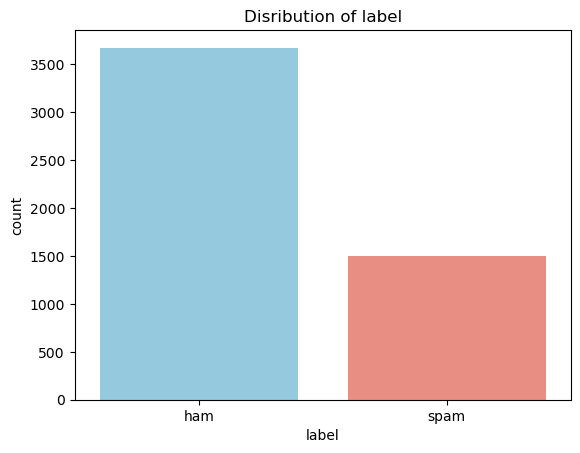

In [19]:
sns.countplot(x='label', data=df, hue="label", palette=["skyblue", "salmon"])
plt.title("Disribution of label")

In [20]:
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].str.split().str.len()

Text(0.5, 1.0, 'Distribution of text length')

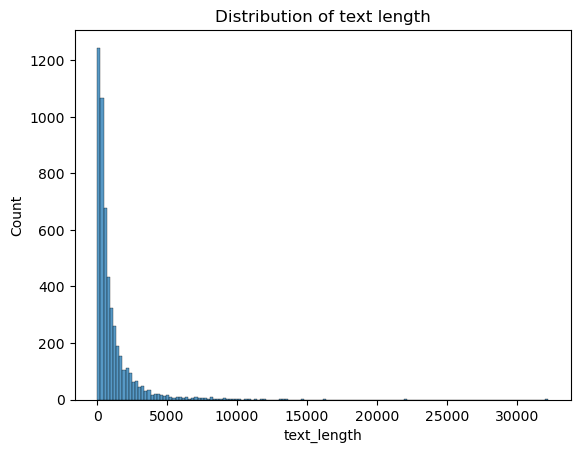

In [21]:
sns.histplot(x='text_length', data=df)
plt.title("Distribution of text length")

Text(0.5, 1.0, 'Distribution of word count')

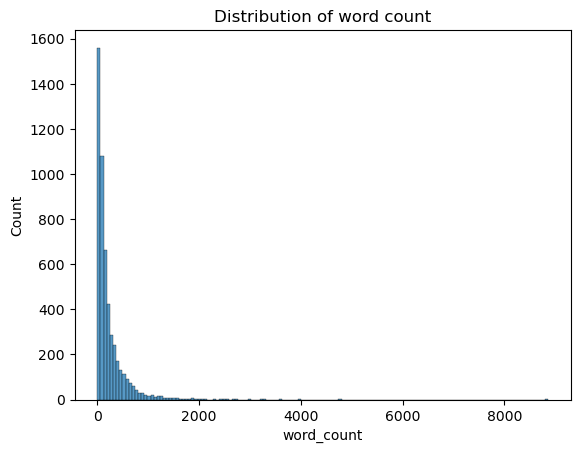

In [22]:
sns.histplot(x='word_count', data=df)
plt.title("Distribution of word count")

### Difference between spam and ham

In [23]:
spam = df[df.label_num == 1]
ham = df[df.label_num == 0]

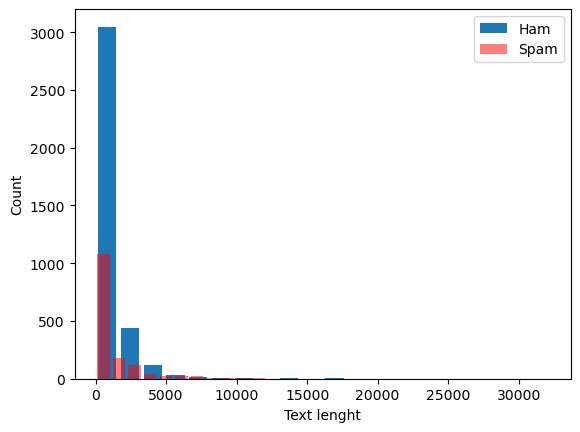

In [26]:
plt.hist(ham.text_length, bins=20, rwidth=0.8, label="Ham")
plt.hist(spam.text_length, bins=20, rwidth=0.8, label="Spam", alpha=0.5, color='red')
plt.xlabel('Text lenght')
plt.ylabel('Count')
plt.legend(loc="upper right");

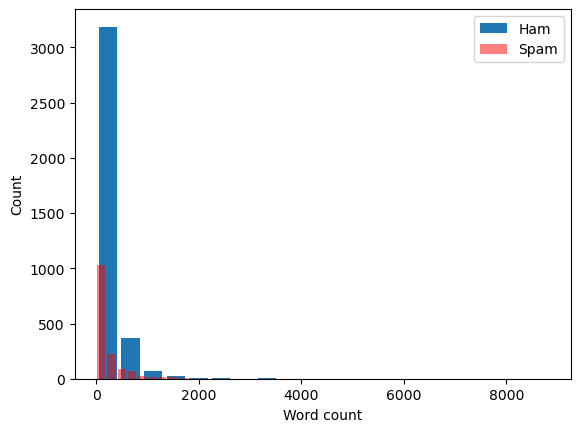

In [27]:
plt.hist(ham.word_count, bins=20, rwidth=0.8, label="Ham")
plt.hist(spam.word_count, bins=20, rwidth=0.8, label="Spam", alpha=0.5, color='red')
plt.xlabel('Word count')
plt.ylabel('Count')
plt.legend(loc="upper right");

### Unique characters

In [28]:
unique_chars = set(list(' '.join(df['text'].values)))
print("".join(unique_chars))

=f]'"m*r-9>;1!^0S6+z@l(hwv2?5_}x,ao[:\c|bj7`%y
$u{ip# ~8.kgt&ds/4q3n


## Baseline models

In [36]:
def clean_text(text):
    """Clean text by removing special characters, numbers, and whitespace."""
    # Convert to lowercase
    text = text.lower()
    # Remove line breaks, tabs, and other whitespace characters
    text = re.sub(r'[\n\r\t]', ' ', text)
    # Keep only letters (a-z) and spaces, remove everything else
    text = re.sub(r'[^a-z\s]', '', text)
    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    # Strip leading/trailing whitespace
    text = text.strip()
    return text

In [37]:
df['cleaned_text'] = df['text'].apply(clean_text)